<a href="https://colab.research.google.com/github/Biswajeetsahu13/jio_mart_stock_price_prediction/blob/main/jio_mart_stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = pd.read_csv('/content/ProductsDB - JioMart.csv')

In [6]:
# Encode categorical features
label_encoders = {}
for col in ['title', 'subType', 'type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# Features and target
X = df[['title', 'price', 'subType', 'type']]
y = df['discountedPrice']

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Model training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [10]:
# Predictions
y_pred = model.predict(X_test)

In [11]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 16.9
R² Score: 0.97


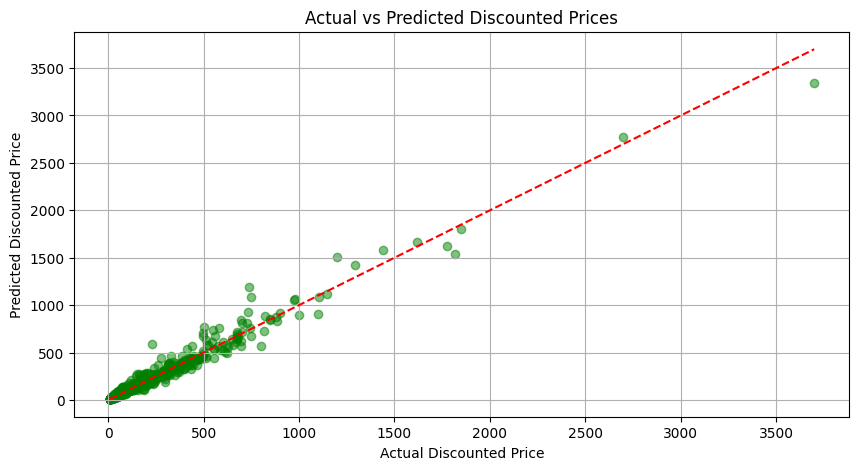

In [12]:
# Visualization
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Discounted Price")
plt.ylabel("Predicted Discounted Price")
plt.title("Actual vs Predicted Discounted Prices")
plt.grid(True)
plt.show()